In [1]:
import json
import os
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import networkx as nx

In [2]:
# ---------------------------------------------------------------------------
# Paleta Steam
# ---------------------------------------------------------------------------
STEAM_DARK   = "#1b2838"
STEAM_BLUE   = "#66c0f4"
STEAM_MID    = "#2a475e"
STEAM_GREEN  = "#4fa83d"
STEAM_RED    = "#c44e52"
STEAM_GREY   = "#8f98a0"
STEAM_WHITE  = "#c6d4df"

In [3]:
# ===========================================================================
# FUNÇÃO DE CARREGAMENTO
# ===========================================================================

def carregar_grafo(
    nodes_path:    str = "nodes.json",
    edges_path:    str = "edges.json",
    edge_types:    list = None,   # None = todos; ou ["review"], ["comment"], ["review","comment"]
    directed:      bool = True,
) -> nx.DiGraph | nx.Graph:
    """
    Lê nodes.json e edges.json (gerados por build_graph.py) e monta um grafo NetworkX.

    Parâmetros
    ----------
    nodes_path  : caminho para o arquivo de nós
    edges_path  : caminho para o arquivo de arestas
    edge_types  : lista de tipos a incluir ("review", "comment"). None = todos.
    directed    : True → DiGraph (padrão, respeita a direcionalidade)
                  False → Graph  (não dirigido, para análises que exigem isso)

    Retorna
    -------
    G : nx.DiGraph ou nx.Graph com atributos nos nós e arestas.

    Atributos dos NÓS
    -----------------
    - review_count  : quantas reviews o usuário fez
    - comment_count : quantos comentários recebeu no perfil

    Atributos das ARESTAS
    ---------------------
    - type     : "review" ou "comment"
    - game     : ID do jogo (só arestas review)
    - src_date : data da review mais antiga (só arestas review)
    - dst_date : data da review mais nova   (só arestas review)
    """
    for path in (nodes_path, edges_path):
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"Arquivo '{path}' não encontrado.\n"
                "Gere os arquivos primeiro com: python build_graph.py steam_data.jsonl"
            )

    edge_types = set(edge_types) if edge_types else None

    G = nx.DiGraph() if directed else nx.Graph()

    # --- Nós ---
    print(f"Carregando nós de '{nodes_path}' ...")
    with open(nodes_path, encoding="utf-8") as f:
        nodes = json.load(f)

    for n in nodes:
        G.add_node(
            n["id"],
            review_count=n.get("review_count", 0),
            comment_count=n.get("comment_count", 0),
        )
    print(f"  {G.number_of_nodes():,} nós adicionados.")

    # --- Arestas ---
    print(f"Carregando arestas de '{edges_path}' ...")
    with open(edges_path, encoding="utf-8") as f:
        edges = json.load(f)

    added = 0
    for e in edges:
        etype = e.get("type", "")
        if edge_types and etype not in edge_types:
            continue
        attrs = {k: v for k, v in e.items() if k not in ("src", "dst")}
        G.add_edge(e["src"], e["dst"], **attrs)
        added += 1

    print(f"  {added:,} arestas adicionadas.")
    print(f"  Grafo {'dirigido' if directed else 'não dirigido'} pronto.\n")
    return G

In [4]:
# ===========================================================================
# ANÁLISE DE ESTATÍSTICAS
# ===========================================================================

def analisar_estatisticas_grafo(G: nx.DiGraph | nx.Graph):
    """
    Imprime estatísticas gerais e plota o histograma de graus.
    Funciona tanto com DiGraph quanto com Graph.
    """
    eh_dirigido = G.is_directed()

    print("\n" + "=" * 50)
    print("  ESTATÍSTICAS GERAIS DO GRAFO")
    print("=" * 50)

    num_nos     = G.number_of_nodes()
    num_arestas = G.number_of_edges()
    print(f"Total de nós   (usuários):   {num_nos:>10,}")
    print(f"Total de arestas (conexões): {num_arestas:>10,}")

    if num_nos == 0:
        print("Grafo vazio!")
        return

    # --- Graus ---
    if eh_dirigido:
        in_deg  = [d for _, d in G.in_degree()]
        out_deg = [d for _, d in G.out_degree()]
        graus   = [i + o for i, o in zip(in_deg, out_deg)]  # grau total
        print(f"\nGrau médio de entrada:  {sum(in_deg)  / num_nos:.2f}")
        print(f"Grau médio de saída:    {sum(out_deg) / num_nos:.2f}")
        print(f"Grau total médio:       {sum(graus)   / num_nos:.2f}")
        print(f"Grau máximo (total):    {max(graus)}")
    else:
        graus = [d for _, d in G.degree()]
        print(f"\nGrau médio:  {sum(graus) / num_nos:.2f}")
        print(f"Grau máximo: {max(graus)}")

    # --- Densidade ---
    densidade = nx.density(G)
    print(f"\nDensidade da rede: {densidade:.8f}")

    # --- Componentes ---
    if eh_dirigido:
        comp_fracos  = nx.number_weakly_connected_components(G)
        print(f"Componentes fracamente conectados: {comp_fracos:,}")
    else:
        comp = nx.number_connected_components(G)
        print(f"Componentes conectados: {comp:,}")

    # --- Clustering (só faz sentido em grafos não dirigidos grandes; usa approximation) ---
    try:
        G_und = G.to_undirected() if eh_dirigido else G
        if num_nos <= 50_000:
            clust = nx.average_clustering(G_und)
            print(f"Coef. de agrupamento médio: {clust:.6f}")
        else:
            import random
            sample = random.sample(list(G_und.nodes()), 5_000)
            clust = nx.average_clustering(G_und, nodes=sample)
            print(f"Coef. de agrupamento médio (amostra 5k nós): {clust:.6f}")
    except Exception as exc:
        print(f"Clustering: não calculado ({exc})")

    # --- Top hubs ---
    print("\n--- TOP 10 NÓS MAIS CONECTADOS (grau total) ---")
    hubs = sorted(
        ((no, G.in_degree(no) + G.out_degree(no)) if eh_dirigido else (no, G.degree(no))
         for no in G.nodes()),
        key=lambda x: x[1], reverse=True
    )[:10]
    for steam_id, grau in hubs:
        dados = G.nodes[steam_id]
        print(f"  ID: {steam_id:<22} | Grau: {grau:>6} "
              f"| Reviews: {dados.get('review_count',0):>4} "
              f"| Comentários recebidos: {dados.get('comment_count',0):>4}")

    # --- Contagem de tipos de arestas ---
    tipos = Counter(d.get("type", "?") for _, _, d in G.edges(data=True))
    print("\n--- ARESTAS POR TIPO ---")
    for t, cnt in tipos.most_common():
        print(f"  {t}: {cnt:,}")

    # --- Histograma ---
    _plotar_histograma_graus(graus, eh_dirigido, in_deg if eh_dirigido else None,
                             out_deg if eh_dirigido else None)


def _plotar_histograma_graus(graus, eh_dirigido, in_deg=None, out_deg=None):
    if eh_dirigido and in_deg is not None:
        fig, axs = plt.subplots(1, 3, figsize=(18, 5))
        fig.patch.set_facecolor(STEAM_DARK)

        datasets = [
            (graus,   "Grau Total",   STEAM_BLUE),
            (in_deg,  "Grau de Entrada (in-degree)",  STEAM_GREEN),
            (out_deg, "Grau de Saída (out-degree)", STEAM_RED),
        ]
        for ax, (data, label, cor) in zip(axs, datasets):
            ax.set_facecolor(STEAM_MID)
            ax.hist(data, bins=60, color=cor, edgecolor=STEAM_DARK, alpha=0.85)
            ax.set_title(label, color=STEAM_WHITE, fontsize=13, fontweight="bold")
            ax.set_xlabel("Grau", color=STEAM_GREY)
            ax.set_ylabel("Frequência", color=STEAM_GREY)
            ax.tick_params(colors=STEAM_GREY)
            ax.grid(axis="y", linestyle="--", alpha=0.4, color=STEAM_GREY)
            for spine in ax.spines.values():
                spine.set_edgecolor(STEAM_GREY)
    else:
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.patch.set_facecolor(STEAM_DARK)
        ax.set_facecolor(STEAM_MID)
        ax.hist(graus, bins=60, color=STEAM_BLUE, edgecolor=STEAM_DARK, alpha=0.85)
        ax.set_xlabel("Grau (Número de Conexões)", color=STEAM_GREY)
        ax.set_ylabel("Frequência (Número de Usuários)", color=STEAM_GREY)
        ax.tick_params(colors=STEAM_GREY)
        ax.grid(axis="y", linestyle="--", alpha=0.4, color=STEAM_GREY)
        for spine in ax.spines.values():
            spine.set_edgecolor(STEAM_GREY)

    fig.suptitle(
        "Distribuição de Graus — Rede Steam",
        color=STEAM_WHITE, fontsize=15, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    plt.show()


# ===========================================================================
# ANÁLISES EXTRAS
# ===========================================================================

def plotar_analises_extras(G: nx.DiGraph | nx.Graph, amostra_grafo: int = 500):
    """
    Plota 4 painéis:
      1. Histograma de reviews por usuário
      2. Histograma de comentários recebidos por usuário
      3. Top 15 jogos com mais conexões de review
      4. Visualização da rede (subamostra para não travar)

    Parâmetros
    ----------
    G            : grafo carregado por carregar_grafo()
    amostra_grafo: quantos nós usar na visualização topológica (painel 4).
                   Reduza se estiver lento; aumente se quiser mais detalhe.
    """
    eh_dirigido = G.is_directed()

    # --- Coleta atributos ---
    review_counts  = []
    comment_counts = []

    for no, dados in G.nodes(data=True):
        review_counts.append(dados.get("review_count", 0))
        comment_counts.append(dados.get("comment_count", 0))

    # --- Contagem de jogos nas arestas de review ---
    game_counter = Counter(
        d["game"]
        for _, _, d in G.edges(data=True)
        if d.get("type") == "review" and "game" in d
    )

    # --- Layout da figura ---
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.patch.set_facecolor(STEAM_DARK)
    fig.suptitle(
        "Análise da Rede de Usuários Steam",
        color=STEAM_WHITE, fontsize=16, fontweight="bold",
    )

    _estilizar_ax = lambda ax, titulo, xlabel, ylabel: (
        ax.set_facecolor(STEAM_MID),
        ax.set_title(titulo, color=STEAM_WHITE, fontsize=12, fontweight="bold"),
        ax.set_xlabel(xlabel, color=STEAM_GREY, fontsize=10),
        ax.set_ylabel(ylabel, color=STEAM_GREY, fontsize=10),
        ax.tick_params(colors=STEAM_GREY),
        ax.grid(axis="y", linestyle="--", alpha=0.4, color=STEAM_GREY),
        [s.set_edgecolor(STEAM_GREY) for s in ax.spines.values()],
    )

    # --- Painel 1: Reviews por usuário ---
    ax1 = axs[0, 0]
    ax1.set_facecolor(STEAM_MID)
    ax1.hist(
        [r for r in review_counts if r > 0],
        bins=50, color=STEAM_BLUE, edgecolor=STEAM_DARK, alpha=0.85,
    )
    _estilizar_ax(ax1, "Distribuição de Reviews por Usuário",
                  "Número de Reviews", "Quantidade de Usuários")
    media_rev = sum(review_counts) / len(review_counts) if review_counts else 0
    ax1.axvline(media_rev, color=STEAM_RED, linestyle="--", linewidth=1.5,
                label=f"Média: {media_rev:.1f}")
    ax1.legend(facecolor=STEAM_DARK, labelcolor=STEAM_WHITE)

    # --- Painel 2: Comentários recebidos por usuário ---
    ax2 = axs[0, 1]
    ax2.set_facecolor(STEAM_MID)
    ax2.hist(
        [c for c in comment_counts if c > 0],
        bins=50, color=STEAM_GREEN, edgecolor=STEAM_DARK, alpha=0.85,
    )
    _estilizar_ax(ax2, "Comentários Recebidos por Usuário",
                  "Número de Comentários Recebidos", "Quantidade de Usuários")
    media_com = sum(comment_counts) / len(comment_counts) if comment_counts else 0
    ax2.axvline(media_com, color=STEAM_RED, linestyle="--", linewidth=1.5,
                label=f"Média: {media_com:.1f}")
    ax2.legend(facecolor=STEAM_DARK, labelcolor=STEAM_WHITE)

    # --- Painel 3: Top 15 jogos mais conectados ---
    ax3 = axs[1, 0]
    ax3.set_facecolor(STEAM_MID)
    if game_counter:
        top_games = game_counter.most_common(15)
        jogos  = [f"App {g[0]}" for g in top_games]
        conts  = [g[1] for g in top_games]
        bars   = ax3.barh(jogos[::-1], conts[::-1], color=STEAM_BLUE,
                          edgecolor=STEAM_DARK, alpha=0.85)
        # Rótulos nas barras
        for bar, val in zip(bars, conts[::-1]):
            ax3.text(bar.get_width() + max(conts) * 0.01, bar.get_y() + bar.get_height() / 2,
                     f"{val:,}", va="center", color=STEAM_WHITE, fontsize=8)
        _estilizar_ax(ax3, "Top 15 Jogos por Conexões de Review",
                      "Número de Arestas de Review", "App ID do Jogo")
    else:
        ax3.text(0.5, 0.5, "Sem arestas de review no grafo",
                 ha="center", va="center", color=STEAM_GREY, fontsize=12)
        ax3.set_title("Top 15 Jogos por Conexões de Review",
                      color=STEAM_WHITE, fontsize=12, fontweight="bold")

    # --- Painel 4: Visualização topológica (subamostra) ---
    ax4 = axs[1, 1]
    ax4.set_facecolor(STEAM_DARK)
    ax4.set_title(
        f"Topologia da Rede (amostra: {amostra_grafo} nós)",
        color=STEAM_WHITE, fontsize=12, fontweight="bold",
    )
    ax4.axis("off")

    nos_todos = list(G.nodes())
    if len(nos_todos) > amostra_grafo:
        import random
        random.seed(42)
        nos_sample = random.sample(nos_todos, amostra_grafo)
    else:
        nos_sample = nos_todos

    G_sub = G.subgraph(nos_sample)

    graus_sub = (
        {n: G_sub.in_degree(n) + G_sub.out_degree(n) for n in G_sub.nodes()}
        if eh_dirigido
        else dict(G_sub.degree())
    )
    tamanhos = [max(graus_sub.get(n, 1) * 8, 10) for n in G_sub.nodes()]

    pos = nx.spring_layout(G_sub, seed=42, k=0.5)
    nx.draw_networkx_nodes(
        G_sub, pos, ax=ax4, node_size=tamanhos,
        node_color=STEAM_BLUE, alpha=0.75,
    )
    nx.draw_networkx_edges(
        G_sub, pos, ax=ax4,
        alpha=0.15, edge_color=STEAM_GREY, width=0.5,
        arrows=eh_dirigido, arrowsize=6,
    )

    plt.tight_layout()
    plt.show()


# ===========================================================================
# BÔNUS: Análise de comunidades (por tipo de aresta)
# ===========================================================================

def plotar_distribuicao_tipos(G: nx.DiGraph | nx.Graph):
    """
    Plota pizza e barras comparando arestas de review vs comentário,
    e mostra grau médio separado por tipo.
    """
    review_edges  = [(u, v) for u, v, d in G.edges(data=True) if d.get("type") == "review"]
    comment_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("type") == "comment"]

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor(STEAM_DARK)
    fig.suptitle("Composição das Arestas do Grafo", color=STEAM_WHITE,
                 fontsize=15, fontweight="bold")

    # Pizza
    ax1 = axs[0]
    ax1.set_facecolor(STEAM_DARK)
    valores = [len(review_edges), len(comment_edges)]
    labels  = [f"Review\n{len(review_edges):,}", f"Comentário\n{len(comment_edges):,}"]
    cores   = [STEAM_BLUE, STEAM_GREEN]
    wedges, texts, autotexts = ax1.pie(
        valores, labels=labels, colors=cores, autopct="%1.1f%%",
        startangle=90, textprops={"color": STEAM_WHITE},
        wedgeprops={"edgecolor": STEAM_DARK, "linewidth": 2},
    )
    for at in autotexts:
        at.set_color(STEAM_DARK)
        at.set_fontweight("bold")
    ax1.set_title("Proporção por Tipo", color=STEAM_WHITE, fontsize=12, fontweight="bold")

    # Grau médio por tipo
    ax2 = axs[1]
    ax2.set_facecolor(STEAM_MID)

    G_rev = nx.DiGraph()
    G_rev.add_edges_from(review_edges)
    G_com = nx.DiGraph()
    G_com.add_edges_from(comment_edges)

    categorias = ["Review\n(out)", "Review\n(in)", "Comentário\n(out)", "Comentário\n(in)"]
    medias = [
        sum(d for _, d in G_rev.out_degree()) / max(G_rev.number_of_nodes(), 1),
        sum(d for _, d in G_rev.in_degree())  / max(G_rev.number_of_nodes(), 1),
        sum(d for _, d in G_com.out_degree()) / max(G_com.number_of_nodes(), 1),
        sum(d for _, d in G_com.in_degree())  / max(G_com.number_of_nodes(), 1),
    ]
    cores_bar = [STEAM_BLUE, STEAM_BLUE, STEAM_GREEN, STEAM_GREEN]
    alphas    = [0.9, 0.5, 0.9, 0.5]

    for i, (cat, med, cor, alp) in enumerate(zip(categorias, medias, cores_bar, alphas)):
        bar = ax2.bar(cat, med, color=cor, alpha=alp, edgecolor=STEAM_DARK)
        ax2.text(i, med + max(medias) * 0.01, f"{med:.2f}",
                 ha="center", color=STEAM_WHITE, fontsize=10, fontweight="bold")

    ax2.set_title("Grau Médio por Tipo de Aresta", color=STEAM_WHITE,
                  fontsize=12, fontweight="bold")
    ax2.set_ylabel("Grau Médio", color=STEAM_GREY)
    ax2.tick_params(colors=STEAM_GREY)
    ax2.grid(axis="y", linestyle="--", alpha=0.4, color=STEAM_GREY)
    for spine in ax2.spines.values():
        spine.set_edgecolor(STEAM_GREY)

    plt.tight_layout()
    plt.show()

Carregando nós de '../dataset/reviews-comment-graph/nodes.json' ...
  67,390 nós adicionados.
Carregando arestas de '../dataset/reviews-comment-graph/edges.json' ...
  682,930 arestas adicionadas.
  Grafo dirigido pronto.


  ESTATÍSTICAS GERAIS DO GRAFO
Total de nós   (usuários):      374,381
Total de arestas (conexões):    682,825

Grau médio de entrada:  1.82
Grau médio de saída:    1.82
Grau total médio:       3.65
Grau máximo (total):    1398

Densidade da rede: 0.00000487
Componentes fracamente conectados: 15,739
Coef. de agrupamento médio (amostra 5k nós): 0.000289

--- TOP 10 NÓS MAIS CONECTADOS (grau total) ---
  ID: Linger                 | Grau:   1398 | Reviews:    0 | Comentários recebidos:    0
  ID: .                      | Grau:    907 | Reviews:    0 | Comentários recebidos:    0
  ID: Lei                    | Grau:    793 | Reviews:    0 | Comentários recebidos:    0
  ID: Dongong                | Grau:    473 | Reviews:    0 | Comentários recebidos:    0
  ID: 󠀡󠀡    

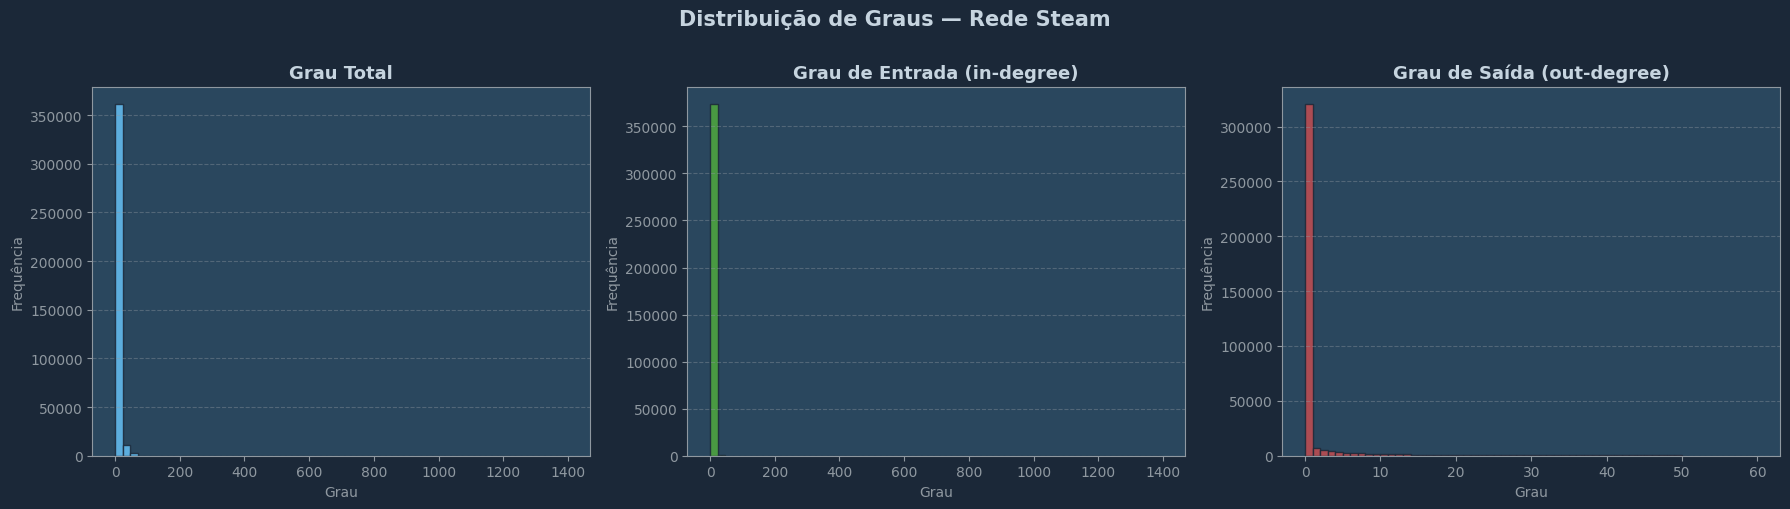

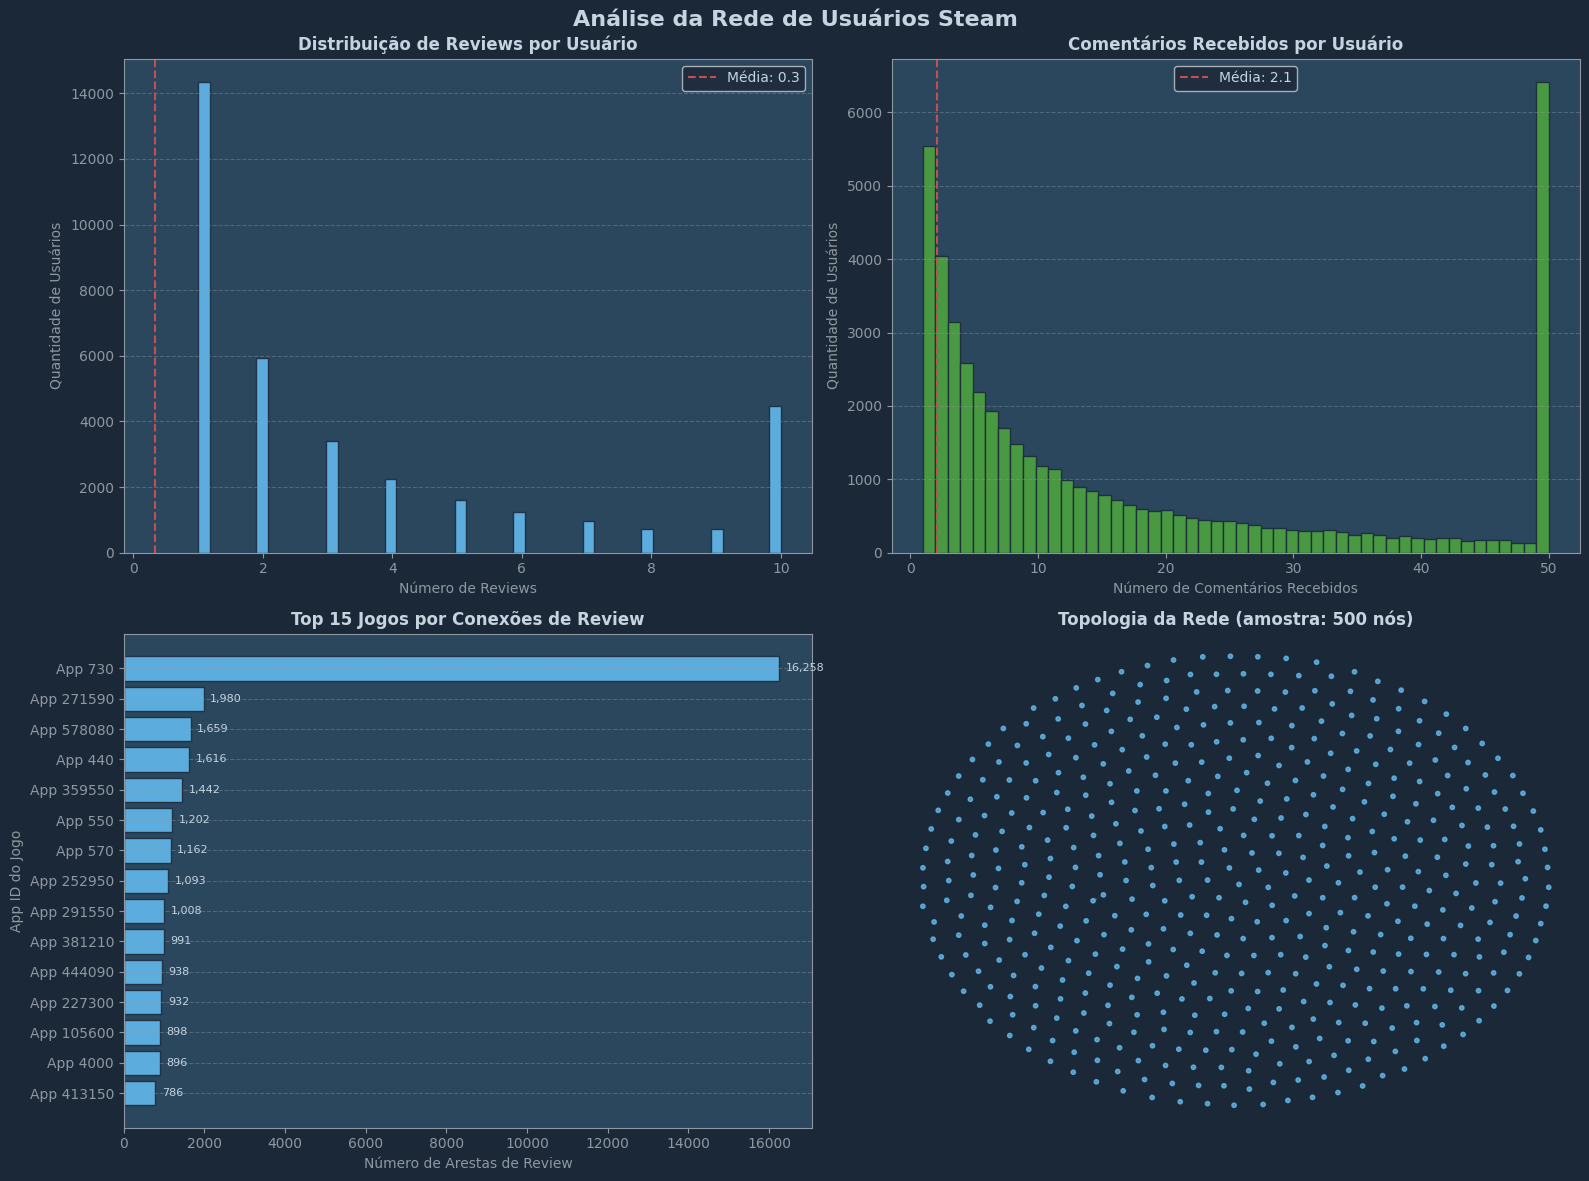

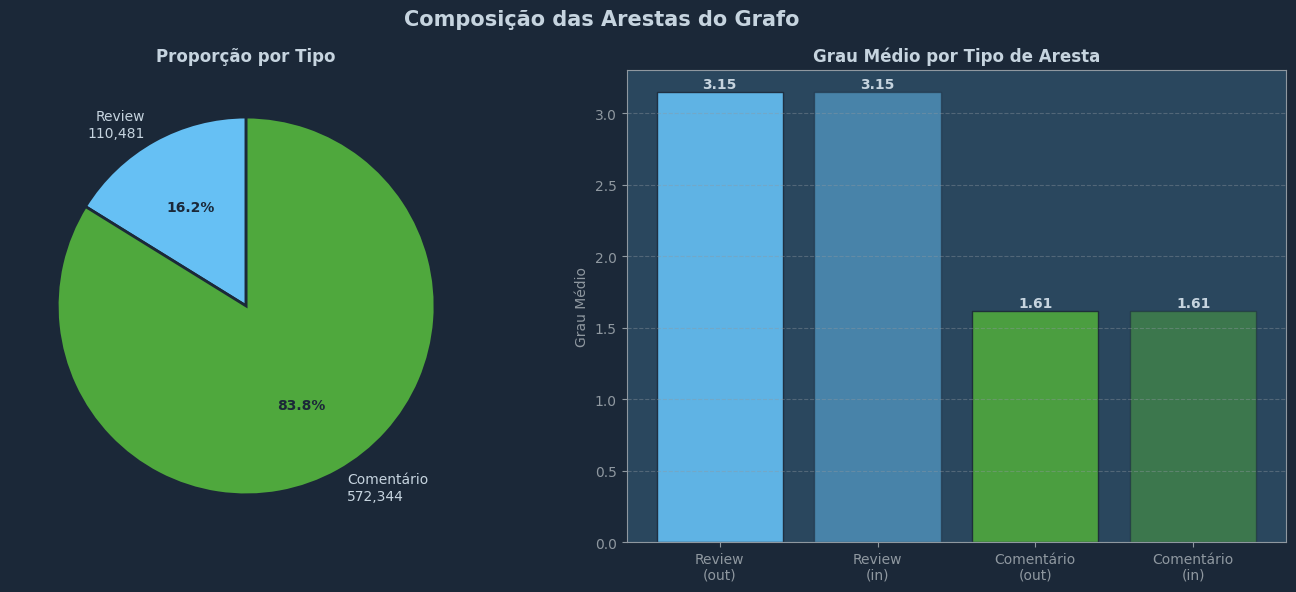

In [5]:
# Carrega o grafo completo (dirigido, todos os tipos de aresta)
G = carregar_grafo(
    nodes_path="../dataset/reviews-comment-graph/nodes.json",
    edges_path="../dataset/reviews-comment-graph/edges.json",
    directed=True,
)

# Estatísticas e histograma de graus
analisar_estatisticas_grafo(G)

# Painéis de análise extra
plotar_analises_extras(G, amostra_grafo=500)

# Distribuição por tipo de aresta
plotar_distribuicao_tipos(G)